# Santander Experiment Notebook

This notebook generates and analyses the Santander Customer Transaction Prediction experiment used in the cross-validation reliability research project.

The purpose of this notebook is not to maximise Kaggle leaderboard rank. Instead, it creates a controlled empirical model-evaluation dataset by training many model configurations and recording their validation behaviour.

## Main Objectives

This notebook performs the following steps:

1. Load the Santander training, test, and sample submission files.
2. Generate 1,000 controlled model configurations across multiple model families.
3. Evaluate each configuration using stratified 5-fold cross-validation.
4. Create Kaggle-compatible submission files.
5. Construct a representative 100-model leaderboard subset.
6. Merge manually verified public and private leaderboard scores.
7. Export the final Santander research dataset used in the Bayesian melding analysis.

## Final Outputs

The main outputs are saved under:

`results/santander/`

Key output files include:

- `santander_1000_model_configs.csv`
- `santander_1000_model_results.csv`
- `manual_submission_plan_100.csv`
- `santander_leaderboard_scores.csv`
- `santander_final_research_dataset.csv`
- `santander_bayesian_melding_input.csv`

## Reproducibility Note

Raw Kaggle competition data is not included in this repository. To reproduce the notebook, download the Santander Customer Transaction Prediction dataset from Kaggle and place the files in:

`data/santander/`

## 1. Setup

This section imports the required Python libraries and sets the random seed used for reproducible model configuration generation.

In [1]:
import os
import json
import time
import warnings
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Project Paths

This section defines the local project paths used by the notebook.

Raw Kaggle data is expected under `data/santander/`.

Experiment outputs are written to `results/santander/`.

Generated submission files are written to `submissions/santander/`, which is ignored by Git because submission CSVs can be large and are not required for the final research analysis.

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "santander"
SUBMISSION_DIR = PROJECT_ROOT / "submissions" / "santander"
RESULTS_DIR = PROJECT_ROOT / "results" / "santander"

SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

COMPETITION_NAME = "santander-customer-transaction-prediction"

RESULTS_CSV = RESULTS_DIR / "santander_1000_model_results.csv"
CONFIG_CSV = RESULTS_DIR / "santander_1000_model_configs.csv"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Submission dir:", SUBMISSION_DIR)
print("Results dir:", RESULTS_DIR)

Project root: ..
Data dir: ../data/santander
Submission dir: ../submissions/santander
Results dir: ../results/santander


## 3. Experiment Controls

This section controls which part of the 1,000-model configuration list is executed.

For repository safety, the default range is empty:

```python
START_INDEX = 0
END_INDEX = 0
```

To reproduce a small test batch, manually change the values to something like:

```python
START_INDEX = 0
END_INDEX = 5
```

Kaggle auto-submission is disabled by default. Do not submit large batches automatically, as Kaggle may enforce submission limits or rate throttling.

In [59]:
# Default to an empty run for repository safety.
# Set START_INDEX and END_INDEX manually when reproducing experiments.
START_INDEX = 0
END_INDEX = 0

AUTO_SUBMIT = False
MAX_SUBMISSIONS_PER_RUN = 1

# 5-fold CV for all generated models.
cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("START_INDEX:", START_INDEX)
print("END_INDEX:", END_INDEX)
print("AUTO_SUBMIT:", AUTO_SUBMIT)
print("MAX_SUBMISSIONS_PER_RUN:", MAX_SUBMISSIONS_PER_RUN)

START_INDEX: 700
END_INDEX: 1000
AUTO_SUBMIT: False
MAX_SUBMISSIONS_PER_RUN: 1


## 4. Load Santander Dataset

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_sub.shape)

display(train_df.head())
display(sample_sub.head())

Train shape: (200000, 202)
Test shape: (200000, 201)
Sample submission shape: (200000, 2)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


,ID_code,target
0,test_0,0
1,test_1,0
2,test_2,0
3,test_3,0
4,test_4,0


In [5]:
TARGET_COL = "target"
ID_COL = "ID_code"

feature_cols = [c for c in train_df.columns if c not in [ID_COL, TARGET_COL]]

X = train_df[feature_cols].copy()
y = train_df[TARGET_COL].copy()
X_test = test_df[feature_cols].copy()

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Number of features: 200
X shape: (200000, 200)
y shape: (200000,)
X_test shape: (200000, 200)

Target distribution:
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


## 5. Generate 1000 Controlled Model Configurations

The experiment uses five model families:

- LightGBM: 350 configurations
- XGBoost: 350 configurations
- CatBoost: 150 configurations
- Random Forest / ExtraTrees: 75 configurations
- Logistic Regression: 75 configurations

This gives 1000 model configurations for the Santander dataset.

In [6]:
def sample_lgbm_config(rng, model_id):
    return {
        "model_id": model_id,
        "model_family": "lightgbm",
        "seed": int(rng.integers(1, 1_000_000)),
        "params": {
            "n_estimators": int(rng.choice([300, 500, 700, 900, 1100])),
            "learning_rate": float(rng.choice([0.01, 0.02, 0.03, 0.05, 0.07])),
            "num_leaves": int(rng.choice([15, 31, 63, 127])),
            "max_depth": int(rng.choice([-1, 3, 5, 7, 9])),
            "min_child_samples": int(rng.choice([10, 20, 40, 80, 120])),
            "subsample": float(rng.choice([0.6, 0.7, 0.8, 0.9, 1.0])),
            "colsample_bytree": float(rng.choice([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])),
            "reg_alpha": float(rng.choice([0.0, 0.01, 0.1, 0.5, 1.0])),
            "reg_lambda": float(rng.choice([0.0, 0.1, 0.5, 1.0, 2.0, 5.0])),
        }
    }


def sample_xgb_config(rng, model_id):
    return {
        "model_id": model_id,
        "model_family": "xgboost",
        "seed": int(rng.integers(1, 1_000_000)),
        "params": {
            "n_estimators": int(rng.choice([300, 500, 700, 900, 1100])),
            "learning_rate": float(rng.choice([0.01, 0.02, 0.03, 0.05, 0.07])),
            "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
            "min_child_weight": float(rng.choice([1, 2, 3, 5, 8, 10])),
            "gamma": float(rng.choice([0.0, 0.01, 0.05, 0.1, 0.3])),
            "subsample": float(rng.choice([0.6, 0.7, 0.8, 0.9, 1.0])),
            "colsample_bytree": float(rng.choice([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])),
            "reg_alpha": float(rng.choice([0.0, 0.01, 0.1, 0.5, 1.0])),
            "reg_lambda": float(rng.choice([0.1, 0.5, 1.0, 2.0, 5.0])),
        }
    }


def sample_catboost_config(rng, model_id):
    return {
        "model_id": model_id,
        "model_family": "catboost",
        "seed": int(rng.integers(1, 1_000_000)),
        "params": {
            "iterations": int(rng.choice([300, 500, 700, 900])),
            "learning_rate": float(rng.choice([0.01, 0.02, 0.03, 0.05, 0.07])),
            "depth": int(rng.choice([4, 5, 6, 7, 8])),
            "l2_leaf_reg": float(rng.choice([1, 3, 5, 7, 10])),
            "random_strength": float(rng.choice([0.5, 1.0, 2.0, 5.0])),
            "bagging_temperature": float(rng.choice([0.0, 0.5, 1.0, 2.0])),
        }
    }


def sample_tree_config(rng, model_id):
    model_family = str(rng.choice(["random_forest", "extra_trees"]))

    return {
        "model_id": model_id,
        "model_family": model_family,
        "seed": int(rng.integers(1, 1_000_000)),
        "params": {
            "n_estimators": int(rng.choice([200, 300, 500])),
            "max_depth": rng.choice([None, 5, 8, 12, 16, 24]).item() if hasattr(rng.choice([None, 5]), "item") else None,
            "min_samples_split": int(rng.choice([2, 5, 10, 20])),
            "min_samples_leaf": int(rng.choice([1, 2, 4, 8])),
            "max_features": str(rng.choice(["sqrt", "log2"])),
            "bootstrap": bool(rng.choice([True, False])) if model_family == "random_forest" else False,
        }
    }


def sample_logreg_config(rng, model_id):
    penalty = str(rng.choice(["l2", "l1"]))
    solver = "liblinear" if penalty == "l1" else str(rng.choice(["lbfgs", "liblinear"]))

    return {
        "model_id": model_id,
        "model_family": "logistic_regression",
        "seed": int(rng.integers(1, 1_000_000)),
        "params": {
            "C": float(rng.choice([0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0])),
            "penalty": penalty,
            "solver": solver,
            "max_iter": 1000,
        }
    }

In [7]:
def create_model_configs(random_state=42):
    rng = np.random.default_rng(random_state)
    configs = []
    model_id = 0

    # LightGBM: 350
    for _ in range(350):
        configs.append(sample_lgbm_config(rng, model_id))
        model_id += 1

    # XGBoost: 350
    for _ in range(350):
        configs.append(sample_xgb_config(rng, model_id))
        model_id += 1

    # CatBoost: 150
    for _ in range(150):
        configs.append(sample_catboost_config(rng, model_id))
        model_id += 1

    # Random Forest / ExtraTrees: 75
    for _ in range(75):
        configs.append(sample_tree_config(rng, model_id))
        model_id += 1

    # Logistic Regression: 75
    for _ in range(75):
        configs.append(sample_logreg_config(rng, model_id))
        model_id += 1

    return configs


model_configs = create_model_configs(RANDOM_STATE)

print("Total configs:", len(model_configs))
pd.DataFrame([
    {
        "model_id": c["model_id"],
        "model_family": c["model_family"],
        "seed": c["seed"],
        "params_json": json.dumps(c["params"])
    }
    for c in model_configs
]).to_csv(CONFIG_CSV, index=False)

print("Saved config table to:", CONFIG_CSV)

display(pd.DataFrame(model_configs).head())

Total configs: 1000
Saved config table to: ../results/santander/santander_1000_model_configs.csv


,model_id,model_family,seed,params
0,0,lightgbm,89251,"{'n_estimators': 900, 'learning_rate': 0.05, '..."
1,1,lightgbm,526479,"{'n_estimators': 1100, 'learning_rate': 0.05, ..."
2,2,lightgbm,500352,"{'n_estimators': 500, 'learning_rate': 0.01, '..."
3,3,lightgbm,450460,"{'n_estimators': 500, 'learning_rate': 0.01, '..."
4,4,lightgbm,165229,"{'n_estimators': 900, 'learning_rate': 0.05, '..."


In [8]:
# Clean max_depth values in tree-based sklearn configs.
# This prevents weird numpy object issues from random sampling.

for config in model_configs:
    if config["model_family"] in ["random_forest", "extra_trees"]:
        md = config["params"].get("max_depth", None)
        if pd.isna(md):
            config["params"]["max_depth"] = None
        elif md is not None:
            config["params"]["max_depth"] = int(md)

## 6. Build Model Pipelines

Each model family uses a consistent preprocessing pipeline.

- Tree/boosting models use median imputation.
- Logistic Regression uses median imputation + standard scaling.

In [9]:
def build_pipeline(config):
    family = config["model_family"]
    params = config["params"].copy()
    seed = config["seed"]

    if family == "lightgbm":
        model = LGBMClassifier(
            **params,
            objective="binary",
            random_state=seed,
            n_jobs=-1,
            verbosity=-1
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    elif family == "xgboost":
        model = XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist"
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    elif family == "catboost":
        model = CatBoostClassifier(
            **params,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    elif family == "random_forest":
        model = RandomForestClassifier(
            **params,
            random_state=seed,
            n_jobs=-1,
            class_weight=None
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    elif family == "extra_trees":
        params.pop("bootstrap", None)

        model = ExtraTreesClassifier(
            **params,
            random_state=seed,
            n_jobs=-1,
            class_weight=None
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    elif family == "logistic_regression":
        model = LogisticRegression(
            **params,
            random_state=seed
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    else:
        raise ValueError(f"Unknown model family: {family}")

    return pipeline

## 7. Kaggle Submission Helpers

These functions:

1. Create a submission CSV
2. Submit the CSV to Kaggle if `AUTO_SUBMIT=True`
3. Read the latest Kaggle public/private score
4. Return those scores for storage in the results CSV

Important: submit in small batches only.

In [10]:
def run_shell_command(command, timeout=300):
    """
    Run a shell command and return stdout/stderr.
    """
    try:
        completed = subprocess.run(
            command,
            shell=True,
            capture_output=True,
            text=True,
            timeout=timeout
        )
        return completed.returncode, completed.stdout, completed.stderr
    except subprocess.TimeoutExpired:
        return 1, "", "Command timed out"


def create_submission(model_id, pipeline, X, y, X_test, sample_sub, submission_dir):
    """
    Fit model on full training data and save test predictions.
    """
    pipeline.fit(X, y)

    test_pred = pipeline.predict_proba(X_test)[:, 1]

    submission = sample_sub.copy()
    submission["target"] = test_pred

    submission_path = submission_dir / f"santander_model_{model_id:04d}.csv"
    submission.to_csv(submission_path, index=False)

    return submission_path


def submit_to_kaggle(submission_path, model_id, model_family):
    """
    Submit a CSV to Kaggle.
    """
    message = f"Santander model {model_id:04d} {model_family}"

    command = (
        f'kaggle competitions submit '
        f'-c {COMPETITION_NAME} '
        f'-f "{submission_path}" '
        f'-m "{message}"'
    )

    returncode, stdout, stderr = run_shell_command(command, timeout=600)

    success = returncode == 0 and "Successfully submitted" in stdout

    return {
        "submitted_to_kaggle": success,
        "submit_stdout": stdout,
        "submit_stderr": stderr
    }


def fetch_kaggle_submissions():
    """
    Fetch Kaggle submissions table using the Kaggle CLI.
    """
    command = f"kaggle competitions submissions -c {COMPETITION_NAME}"
    returncode, stdout, stderr = run_shell_command(command, timeout=300)

    if returncode != 0:
        print("Could not fetch submissions.")
        print(stderr)
        return None

    print(stdout)
    return stdout


def parse_latest_scores_from_cli_output(stdout, filename):
    """
    Parse public/private scores from Kaggle CLI output.

    This is a simple parser based on matching the file name line.
    It may need adjustment if Kaggle CLI output format changes.
    """
    if stdout is None:
        return None, None, "NO_OUTPUT"

    lines = stdout.splitlines()

    matching_lines = [line for line in lines if filename in line]

    if len(matching_lines) == 0:
        return None, None, "NOT_FOUND"

    line = matching_lines[0]
    parts = line.split()

    # Public and private scores are usually the last two columns.
    try:
        public_score = float(parts[-2])
        private_score = float(parts[-1])
        status = "COMPLETE"
    except Exception:
        public_score = None
        private_score = None
        status = "PARSE_FAILED"

    return public_score, private_score, status

## 8. Evaluation Function

For each model configuration, we calculate 5-fold CV AUC.

Then we fit on the full training set and create a submission file.

If `AUTO_SUBMIT=True`, the notebook submits the file to Kaggle and tries to collect public/private scores automatically.

In [23]:
def evaluate_single_config(config, X, y, X_test, sample_sub, auto_submit=False):
    model_id = config["model_id"]
    family = config["model_family"]
    seed = config["seed"]
    params = config["params"]

    print(f"\nRunning model_id={model_id}, family={family}")

    pipeline = build_pipeline(config)

    start_time = time.time()

    result = {
        "competition": "santander",
        "model_id": model_id,
        "model_family": family,
        "seed": seed,
        "params_json": json.dumps(params),
        "started_at": datetime.now().isoformat(),
        "cv_auc_mean": None,
        "cv_auc_std": None,
        "cv_auc_min": None,
        "cv_auc_max": None,
        "submission_path": None,
        "submitted_to_kaggle": False,
        "kaggle_status": None,
        "public_auc": None,
        "private_auc": None,
        "runtime_seconds": None,
        "error": None
    }

    try:
        cv_scores = cross_val_score(
            pipeline,
            X,
            y,
            scoring="roc_auc",
            cv=cv_5,
            n_jobs=-1
        )

        result["cv_auc_mean"] = float(np.mean(cv_scores))
        result["cv_auc_std"] = float(np.std(cv_scores))
        result["cv_auc_min"] = float(np.min(cv_scores))
        result["cv_auc_max"] = float(np.max(cv_scores))

        print("CV AUC mean:", result["cv_auc_mean"])
        print("CV AUC std:", result["cv_auc_std"])

        submission_path = create_submission(
            model_id=model_id,
            pipeline=pipeline,
            X=X,
            y=y,
            X_test=X_test,
            sample_sub=sample_sub,
            submission_dir=SUBMISSION_DIR
        )

        result["submission_path"] = str(submission_path)

        if auto_submit:
            submit_result = submit_to_kaggle(
                submission_path=submission_path,
                model_id=model_id,
                model_family=family
            )

            result["submitted_to_kaggle"] = bool(submit_result["submitted_to_kaggle"])

            if result["submitted_to_kaggle"]:
                print("Submitted successfully. Waiting before fetching score...")
                time.sleep(90)

                stdout = fetch_kaggle_submissions()

                public_auc, private_auc, status = parse_latest_scores_from_cli_output(
                    stdout=stdout,
                    filename=submission_path.name
                )

                result["public_auc"] = public_auc
                result["private_auc"] = private_auc
                result["kaggle_status"] = status
            else:
                result["kaggle_status"] = "SUBMISSION_FAILED"
                result["error"] = submit_result["submit_stderr"]

    except Exception as e:
        result["error"] = repr(e)
        print("ERROR:", repr(e))

    result["runtime_seconds"] = float(time.time() - start_time)
    result["finished_at"] = datetime.now().isoformat()

    return result

## 9. Resume Existing Results

This cell loads existing results if the notebook has already been run before.

This allows the experiment to resume without repeating completed models.

In [52]:
if RESULTS_CSV.exists():
    existing_results_df = pd.read_csv(RESULTS_CSV)
    completed_ids = set(existing_results_df["model_id"].astype(int).tolist())
    print("Loaded existing results:", existing_results_df.shape)
    print("Completed model ids:", len(completed_ids))
else:
    existing_results_df = pd.DataFrame()
    completed_ids = set()
    print("No existing results found.")

Loaded existing results: (50, 22)
Completed model ids: 50


## 10. Run Experiment Batch

Start with a small batch.

Recommended first run:

```python
START_INDEX = 0
END_INDEX = 5
AUTO_SUBMIT = False
```

After confirming everything works, increase the range.

When submitting to Kaggle, keep `MAX_SUBMISSIONS_PER_RUN` small.

In [60]:
batch_configs = model_configs[START_INDEX:END_INDEX]

new_results = []
submission_count = 0

for config in batch_configs:
    model_id = int(config["model_id"])

    if model_id in completed_ids:
        print(f"Skipping model_id={model_id}; already completed.")
        continue

    should_submit = AUTO_SUBMIT and (submission_count < MAX_SUBMISSIONS_PER_RUN)

    result = evaluate_single_config(
        config=config,
        X=X,
        y=y,
        X_test=X_test,
        sample_sub=sample_sub,
        auto_submit=should_submit
    )

    if should_submit:
        submission_count += 1

    new_results.append(result)

    # Save after every model so progress is not lost.
    temp_df = pd.DataFrame(new_results)

    if RESULTS_CSV.exists():
        old_df = pd.read_csv(RESULTS_CSV)
        combined_df = pd.concat([old_df, temp_df], ignore_index=True)
        combined_df = combined_df.drop_duplicates(subset=["model_id"], keep="last")
    else:
        combined_df = temp_df.copy()

    combined_df.to_csv(RESULTS_CSV, index=False)

    print(f"Saved progress to {RESULTS_CSV}")

print("Batch complete.")
print("New results:", len(new_results))


Running model_id=700, family=catboost
CV AUC mean: 0.8812214088275916
CV AUC std: 0.0032218444009095215
Saved progress to ../results/santander/santander_1000_model_results.csv

Running model_id=701, family=catboost
CV AUC mean: 0.8435717996745062
CV AUC std: 0.003256046739515433
Saved progress to ../results/santander/santander_1000_model_results.csv

Running model_id=702, family=catboost
CV AUC mean: 0.8891603360054126
CV AUC std: 0.0032978782559411465
Saved progress to ../results/santander/santander_1000_model_results.csv

Running model_id=703, family=catboost
CV AUC mean: 0.8580081007311506
CV AUC std: 0.0032126806920209226
Saved progress to ../results/santander/santander_1000_model_results.csv

Running model_id=704, family=catboost
CV AUC mean: 0.8936698940706872
CV AUC std: 0.00287307244231774
Saved progress to ../results/santander/santander_1000_model_results.csv

Running model_id=705, family=catboost
CV AUC mean: 0.8935631513900217
CV AUC std: 0.002687402803253725
Saved progress

In [54]:
results_df = pd.read_csv(RESULTS_CSV)

print("Results shape:", results_df.shape)
display(results_df.tail())

print("\nModel family counts:")
display(results_df["model_family"].value_counts())

print("\nSubmission status:")
display(results_df["submitted_to_kaggle"].value_counts(dropna=False))

Results shape: (700, 22)


,competition,model_id,model_family,seed,params_json,started_at,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,...,kaggle_status,public_auc,private_auc,runtime_seconds,error,finished_at,cv_private_gap,abs_cv_private_gap,public_private_gap,abs_public_private_gap
695,santander,695,xgboost,432335,"{""n_estimators"": 1100, ""learning_rate"": 0.07, ...",2026-05-10T19:16:24.593720,0.891114,0.002775,0.885904,0.893728,...,NaN,NaN,NaN,159.706964,NaN,2026-05-10T19:19:04.300676,NaN,NaN,NaN,NaN
696,santander,696,xgboost,442149,"{""n_estimators"": 500, ""learning_rate"": 0.05, ""...",2026-05-10T19:19:04.319066,0.874270,0.003531,0.867773,0.878091,...,NaN,NaN,NaN,62.486246,NaN,2026-05-10T19:20:06.805302,NaN,NaN,NaN,NaN
697,santander,697,xgboost,749729,"{""n_estimators"": 500, ""learning_rate"": 0.05, ""...",2026-05-10T19:20:06.819457,0.881168,0.003509,0.874561,0.884468,...,NaN,NaN,NaN,70.856670,NaN,2026-05-10T19:21:17.676118,NaN,NaN,NaN,NaN
698,santander,698,xgboost,588268,"{""n_estimators"": 1100, ""learning_rate"": 0.01, ...",2026-05-10T19:21:17.690857,0.877325,0.003338,0.870932,0.880513,...,NaN,NaN,NaN,221.790746,NaN,2026-05-10T19:24:59.481595,NaN,NaN,NaN,NaN
699,santander,699,xgboost,816357,"{""n_estimators"": 500, ""learning_rate"": 0.05, ""...",2026-05-10T19:24:59.498090,0.886200,0.002554,0.881266,0.888389,...,NaN,NaN,NaN,95.570195,NaN,2026-05-10T19:26:35.068276,NaN,NaN,NaN,NaN



Model family counts:


model_family
lightgbm    350
xgboost     350
Name: count, dtype: int64


Submission status:


submitted_to_kaggle
False    699
True       1
Name: count, dtype: int64

## 11. Validation Reliability Metrics

Once public and private leaderboard scores are available, calculate:

- CV bias: `cv_auc_mean - private_auc`
- Public leaderboard bias: `public_auc - private_auc`
- Absolute CV-private gap
- Absolute public-private gap

These metrics are the empirical foundation for the Bayesian melding model.

In [55]:
results_df = pd.read_csv(RESULTS_CSV)

results_df["cv_private_gap"] = results_df["cv_auc_mean"] - results_df["private_auc"]
results_df["abs_cv_private_gap"] = results_df["cv_private_gap"].abs()

results_df["public_private_gap"] = results_df["public_auc"] - results_df["private_auc"]
results_df["abs_public_private_gap"] = results_df["public_private_gap"].abs()

results_df.to_csv(RESULTS_CSV, index=False)

scored_df = results_df.dropna(subset=["public_auc", "private_auc"]).copy()

print("Total results:", len(results_df))
print("Rows with Kaggle public/private scores:", len(scored_df))

display(scored_df.head())

Total results: 700
Rows with Kaggle public/private scores: 1


,competition,model_id,model_family,seed,params_json,started_at,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,...,kaggle_status,public_auc,private_auc,runtime_seconds,error,finished_at,cv_private_gap,abs_cv_private_gap,public_private_gap,abs_public_private_gap
5,santander,5,lightgbm,759899,"{""n_estimators"": 300, ""learning_rate"": 0.02, ""...",2026-05-09T21:44:22.964176,0.842029,0.003576,0.83614,0.846747,...,COMPLETE,0.84053,0.83816,124.96117,NaN,2026-05-09T21:46:27.925343,0.003869,0.003869,0.00237,0.00237


In [46]:
if len(scored_df) > 0:
    summary_by_family = scored_df.groupby("model_family").agg(
        n_models=("model_id", "count"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        mean_public_auc=("public_auc", "mean"),
        mean_private_auc=("private_auc", "mean"),
        mean_cv_private_gap=("cv_private_gap", "mean"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        mean_public_private_gap=("public_private_gap", "mean"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean"),
        mean_cv_std=("cv_auc_std", "mean")
    ).reset_index()

    display(summary_by_family)

    summary_path = RESULTS_DIR / "santander_summary_by_family.csv"
    summary_by_family.to_csv(summary_path, index=False)
    print("Saved:", summary_path)
else:
    print("No scored Kaggle submissions yet.")

,model_family,n_models,mean_cv_auc,mean_public_auc,mean_private_auc,mean_cv_private_gap,mean_abs_cv_private_gap,mean_public_private_gap,mean_abs_public_private_gap,mean_cv_std
0,lightgbm,1,0.842029,0.84053,0.83816,0.003869,0.003869,0.00237,0.00237,0.003576


Saved: ../results/santander/santander_summary_by_family.csv


In [47]:
if len(scored_df) >= 3:
    corr_cols = ["cv_auc_mean", "public_auc", "private_auc"]
    corr_matrix = scored_df[corr_cols].corr()

    print("Correlation matrix:")
    display(corr_matrix)

    corr_path = RESULTS_DIR / "santander_score_correlations.csv"
    corr_matrix.to_csv(corr_path)
    print("Saved:", corr_path)
else:
    print("Need at least 3 scored submissions for correlation analysis.")

Need at least 3 scored submissions for correlation analysis.


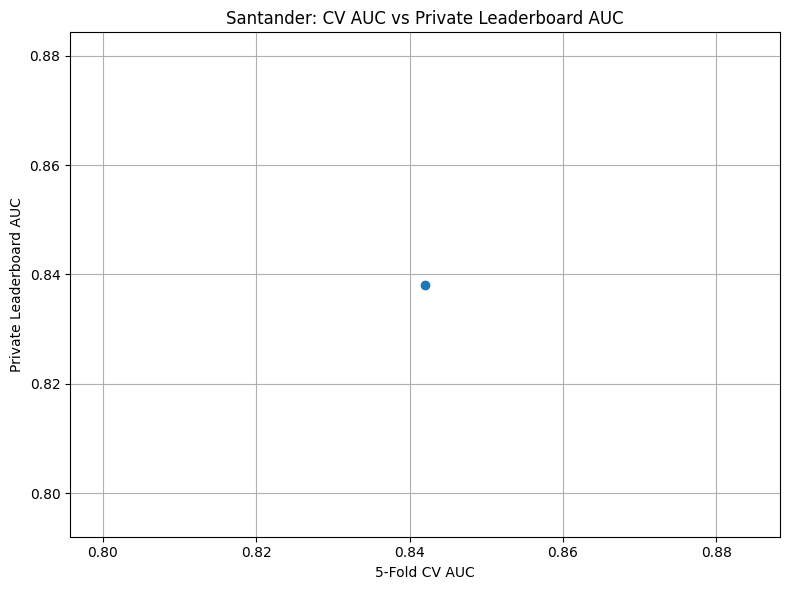

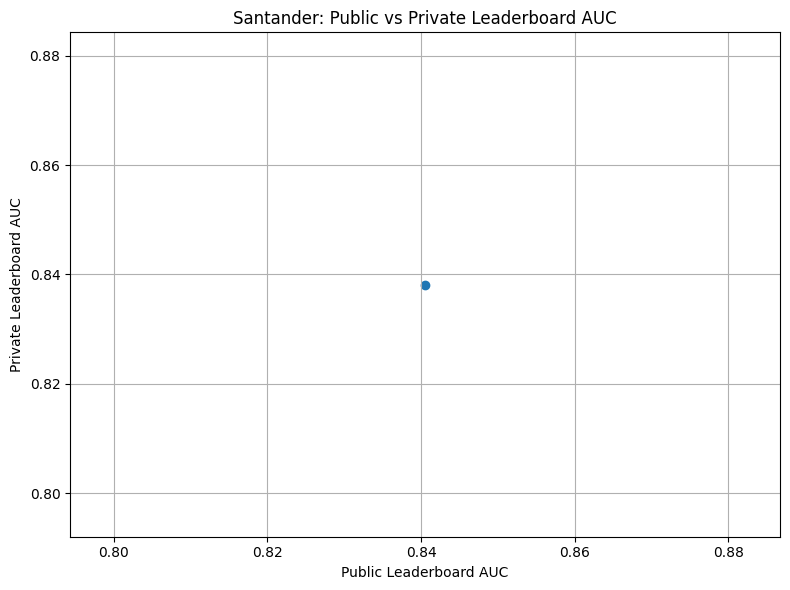

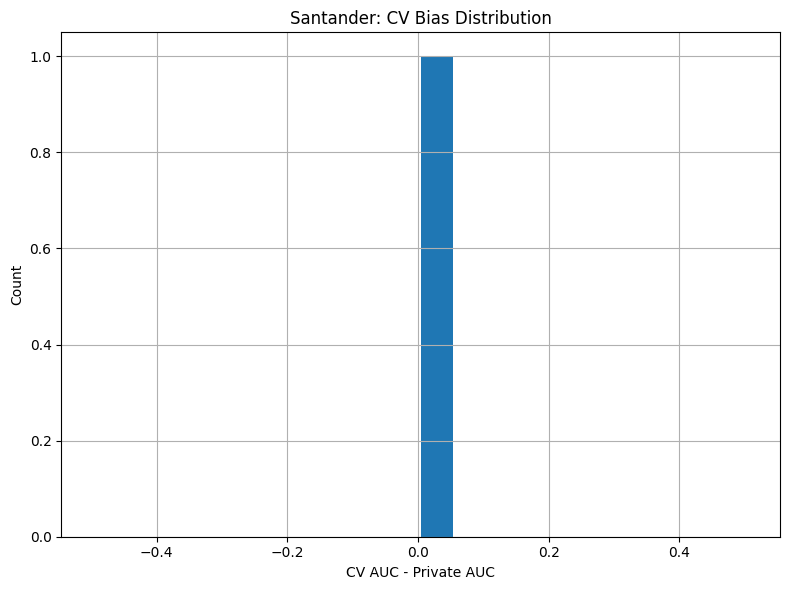

In [48]:
if len(scored_df) > 0:
    plt.figure(figsize=(8, 6))
    plt.scatter(scored_df["cv_auc_mean"], scored_df["private_auc"])
    plt.xlabel("5-Fold CV AUC")
    plt.ylabel("Private Leaderboard AUC")
    plt.title("Santander: CV AUC vs Private Leaderboard AUC")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(scored_df["public_auc"], scored_df["private_auc"])
    plt.xlabel("Public Leaderboard AUC")
    plt.ylabel("Private Leaderboard AUC")
    plt.title("Santander: Public vs Private Leaderboard AUC")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.hist(scored_df["cv_private_gap"], bins=20)
    plt.xlabel("CV AUC - Private AUC")
    plt.ylabel("Count")
    plt.title("Santander: CV Bias Distribution")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No scored rows available for plotting.")

In [56]:
results_df = pd.read_csv(RESULTS_CSV)

bayesian_cols = [
    "competition",
    "model_id",
    "model_family",
    "seed",
    "params_json",
    "cv_auc_mean",
    "cv_auc_std",
    "cv_auc_min",
    "cv_auc_max",
    "public_auc",
    "private_auc",
    "cv_private_gap",
    "abs_cv_private_gap",
    "public_private_gap",
    "abs_public_private_gap",
    "runtime_seconds"
]

available_cols = [c for c in bayesian_cols if c in results_df.columns]

bayesian_df = results_df[available_cols].copy()

bayesian_output_path = RESULTS_DIR / "santander_bayesian_melding_input.csv"
bayesian_df.to_csv(bayesian_output_path, index=False)

print("Saved Bayesian melding input dataset to:")
print(bayesian_output_path)

display(bayesian_df.head())

Saved Bayesian melding input dataset to:
../results/santander/santander_bayesian_melding_input.csv


,competition,model_id,model_family,seed,params_json,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,public_auc,private_auc,cv_private_gap,abs_cv_private_gap,public_private_gap,abs_public_private_gap,runtime_seconds
0,santander,0,lightgbm,89251,"{""n_estimators"": 900, ""learning_rate"": 0.05, ""...",0.889728,0.002818,0.884272,0.891965,NaN,NaN,NaN,NaN,NaN,NaN,95.393856
1,santander,1,lightgbm,526479,"{""n_estimators"": 1100, ""learning_rate"": 0.05, ...",0.889192,0.001899,0.885516,0.890977,NaN,NaN,NaN,NaN,NaN,NaN,119.814146
2,santander,2,lightgbm,500352,"{""n_estimators"": 500, ""learning_rate"": 0.01, ""...",0.850518,0.003843,0.843968,0.855834,NaN,NaN,NaN,NaN,NaN,NaN,87.007270
3,santander,3,lightgbm,450460,"{""n_estimators"": 500, ""learning_rate"": 0.01, ""...",0.855446,0.003695,0.848831,0.860221,NaN,NaN,NaN,NaN,NaN,NaN,111.966728
4,santander,4,lightgbm,165229,"{""n_estimators"": 900, ""learning_rate"": 0.05, ""...",0.892348,0.002643,0.887471,0.895040,NaN,NaN,NaN,NaN,NaN,NaN,172.636391


In [58]:
results_df = pd.read_csv(RESULTS_CSV)

print("Shape:", results_df.shape)

display(results_df["model_family"].value_counts())

summary = results_df.groupby("model_family").agg(
    n_models=("model_id", "count"),
    mean_cv=("cv_auc_mean", "mean"),
    std_cv=("cv_auc_mean", "std"),
    min_cv=("cv_auc_mean", "min"),
    max_cv=("cv_auc_mean", "max"),
    mean_fold_std=("cv_auc_std", "mean"),
    mean_runtime=("runtime_seconds", "mean")
).reset_index()

display(summary.sort_values("mean_cv", ascending=False))

display(
    results_df.sort_values("cv_auc_mean", ascending=False)
    [["model_id", "model_family", "cv_auc_mean", "cv_auc_std", "runtime_seconds"]]
    .head(20)
)

Shape: (700, 22)


model_family
lightgbm    350
xgboost     350
Name: count, dtype: int64

,model_family,n_models,mean_cv,std_cv,min_cv,max_cv,mean_fold_std,mean_runtime
1,xgboost,350,0.872785,0.018876,0.786212,0.894661,0.003331,117.768667
0,lightgbm,350,0.872761,0.020897,0.785353,0.894082,0.003300,101.078241


,model_id,model_family,cv_auc_mean,cv_auc_std,runtime_seconds
472,472,xgboost,0.894661,0.002756,135.468755
462,462,xgboost,0.894470,0.002423,125.415334
294,294,lightgbm,0.894082,0.003190,122.331770
169,169,lightgbm,0.893957,0.002295,133.588933
479,479,xgboost,0.893952,0.002559,149.416798
84,84,lightgbm,0.893764,0.002688,88.280971
371,371,xgboost,0.893757,0.002653,144.169865
81,81,lightgbm,0.893692,0.002318,107.758518
19,19,lightgbm,0.893636,0.002746,103.919501
412,412,xgboost,0.893617,0.002449,143.185722


## 12. Representative Leaderboard Subset Selection

This section selects a representative subset of 100 Santander models for leaderboard evaluation.

The subset is selected across model families and cross-validation performance ranges rather than taking only the best-performing models. This reduces cherry-picking risk and supports fairer validation reliability analysis.

Random Forest and ExtraTrees are grouped into a combined `bagging_trees` category for subset allocation.

In [75]:
results_df = pd.read_csv(RESULTS_CSV)

# Keep only rows with generated submission files.
available_df = results_df[
    results_df["submission_path"].notna()
].copy()

# Treat Random Forest and ExtraTrees as one combined bagging family.
available_df["submission_family"] = available_df["model_family"].replace({
    "random_forest": "bagging_trees",
    "extra_trees": "bagging_trees"
})

family_quota = {
    "lightgbm": 25,
    "xgboost": 25,
    "catboost": 20,
    "bagging_trees": 15,
    "logistic_regression": 15
}

def select_top_middle_bottom(group_df, n_select):
    group_df = group_df.sort_values("cv_auc_mean").copy()

    n_bottom = n_select // 3
    n_top = n_select // 3
    n_middle = n_select - n_bottom - n_top

    bottom = group_df.head(n_bottom)
    top = group_df.tail(n_top)

    median_cv = group_df["cv_auc_mean"].median()
    middle = (
        group_df
        .assign(distance_to_median=(group_df["cv_auc_mean"] - median_cv).abs())
        .sort_values("distance_to_median")
        .head(n_middle)
    )

    selected = pd.concat([top, middle, bottom], ignore_index=True)
    selected = selected.drop_duplicates(subset=["model_id"])

    return selected

selected_parts = []

for family, quota in family_quota.items():
    family_df = available_df[available_df["submission_family"] == family].copy()

    selected_family = select_top_middle_bottom(
        group_df=family_df,
        n_select=quota
    )

    selected_parts.append(selected_family)

manual_submission_plan = (
    pd.concat(selected_parts, ignore_index=True)
    .drop_duplicates(subset=["model_id"])
    .sort_values(["submission_family", "cv_auc_mean"], ascending=[True, False])
)

manual_submission_plan_path = RESULTS_DIR / "manual_submission_plan_100.csv"
manual_submission_plan.to_csv(manual_submission_plan_path, index=False)

print("Manual submission plan size:", len(manual_submission_plan))
print("Saved to:", manual_submission_plan_path)

display(
    manual_submission_plan[
        [
            "model_id",
            "model_family",
            "submission_family",
            "cv_auc_mean",
            "cv_auc_std",
            "submission_path"
        ]
    ]
)

Manual submission plan size: 100
Saved to: ../results/santander/manual_submission_plan_100.csv


,model_id,model_family,submission_family,cv_auc_mean,cv_auc_std,submission_path
74,897,extra_trees,bagging_trees,0.877306,0.002998,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
73,920,extra_trees,bagging_trees,0.877222,0.003241,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
72,889,extra_trees,bagging_trees,0.874489,0.003800,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
71,893,extra_trees,bagging_trees,0.872614,0.003722,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
70,914,extra_trees,bagging_trees,0.872134,0.004218,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
...,...,...,...,...,...,...
46,630,xgboost,xgboost,0.813279,0.004251,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
45,631,xgboost,xgboost,0.812329,0.004034,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
44,385,xgboost,xgboost,0.805393,0.004878,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...
43,576,xgboost,xgboost,0.790928,0.005571,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...


## 13. Manual Leaderboard Score Integration

This section records the manually verified Kaggle public and private leaderboard scores for the selected Santander representative models.

Leaderboard scores were collected manually because large-scale automated submission and score retrieval was limited by Kaggle submission-rate constraints.

The manually verified scores are saved as `santander_leaderboard_scores.csv`.

In [116]:
# MANUAL SANTANDER LEADERBOARD SCORES
leaderboard_records = [
    # model_id, public_auc, private_auc
    [10, 0.88063, 0.87641],
    [19, 0.89457, 0.89159],
    [52, 0.78596, 0.78164],
    [67, 0.89304, 0.89027],
    [72, 0.89470, 0.89052],
    [75, 0.81146, 0.80607],
    [81, 0.89509, 0.89165],
    [84, 0.89444, 0.89133],
    [86, 0.88044, 0.87764],
    [117, 0.87972, 0.87655],
    [143, 0.78526, 0.78079],
    [145, 0.80686, 0.80215],
    [154, 0.80995, 0.80521],
    [168, 0.78516, 0.78157],
    [169, 0.89549, 0.89218],
    [184, 0.88151, 0.87819],
    [190, 0.88002, 0.87708],
    [222, 0.80967, 0.80400],
    [240, 0.88056, 0.87698],
    [244, 0.80728, 0.80226],
    [253, 0.89443, 0.89139],
    [274, 0.87930, 0.87647],
    [294, 0.89452, 0.89197],
    [327, 0.88035, 0.87648],
    [339, 0.87949, 0.87703],
    [371, 0.89479, 0.89164],
    [385, 0.80290, 0.79875],
    [387, 0.87961, 0.87643],
    [412, 0.89388, 0.89262],
    [441, 0.87853, 0.87504],
    [442, 0.89357, 0.89090],
    [445, 0.87865, 0.87489],
    [455, 0.81539, 0.81233],
    [459, 0.81938, 0.81532],
    [462, 0.89455, 0.89210],
    [472, 0.89414, 0.89182],
    [479, 0.89545, 0.89206],
    [484, 0.78554, 0.78129],
    [505, 0.87872, 0.87581],
    [532, 0.89324, 0.88967],
    [563, 0.87810, 0.87465],
    [571, 0.89328, 0.89010],
    [576, 0.78954, 0.78533],
    [585, 0.87828, 0.87430],
    [618, 0.87878, 0.87497],
    [619, 0.81918, 0.81472],
    [630, 0.81194, 0.80697],
    [631, 0.81167, 0.80724],
    [676, 0.87862, 0.87642],
    [681, 0.87794, 0.87413],
    [704, 0.89369, 0.89115],
    [707, 0.87194, 0.86984],
    [709, 0.81027, 0.80724],
    [724, 0.89444, 0.89141],
    [725, 0.86932, 0.86703],
    [751, 0.81426, 0.81085],
    [755, 0.87112, 0.86838],
    [761, 0.89516, 0.89267],
    [762, 0.89398, 0.89237],
    [764, 0.89401, 0.89191],
    [767, 0.86864, 0.86606],
    [769, 0.89418, 0.89150],
    [783, 0.80744, 0.80351],
    [785, 0.81799, 0.81422],
    [819, 0.87109, 0.86856],
    [822, 0.79548, 0.79184],
    [825, 0.87187, 0.86960],
    [827, 0.86845, 0.86580],
    [833, 0.87176, 0.86944],
    [841, 0.81599, 0.81226],
    [862, 0.83842, 0.83584],
    [864, 0.84184, 0.83639],
    [866, 0.85735, 0.85446],
    [868, 0.85447, 0.85206],
    [880, 0.85826, 0.85503],
    [886, 0.85720, 0.85444],
    [887, 0.84407, 0.83921],
    [889, 0.87385, 0.87221],
    [893, 0.87305, 0.87045],
    [894, 0.84299, 0.83937],
    [897, 0.87624, 0.87653],
    [900, 0.85901, 0.85604],
    [914, 0.87229, 0.86799],
    [920, 0.87754, 0.87564],
    [921, 0.83416, 0.83414],
    [930, 0.86096, 0.86066],
    [935, 0.86094, 0.86064],
    [937, 0.86096, 0.86066],
    [940, 0.86094, 0.86064],
    [941, 0.84430, 0.84406],
    [942, 0.84430, 0.84406],
    [943, 0.84430, 0.84406],
    [944, 0.86101, 0.86068],
    [945, 0.86094, 0.86064],
    [951, 0.86098, 0.86067],
    [953, 0.84430, 0.84406],
    [963, 0.84430, 0.84406],
    [970, 0.86097, 0.86066],
    [974, 0.86094, 0.86064],
    [978, 0.86094, 0.86064],
]

leaderboard_df = pd.DataFrame(
    leaderboard_records,
    columns=["model_id", "public_auc", "private_auc"]
)

leaderboard_df = (
    leaderboard_df
    .drop_duplicates(subset=["model_id"], keep="first")
    .sort_values("model_id")
    .reset_index(drop=True)
)

leaderboard_path = RESULTS_DIR / "santander_leaderboard_scores.csv"

leaderboard_df.to_csv(leaderboard_path, index=False)

print("Santander leaderboard rows:", len(leaderboard_df))
print("Saved leaderboard scores to:", leaderboard_path)

display(leaderboard_df.head())
display(leaderboard_df.tail())

Santander leaderboard rows: 100
Saved leaderboard scores to: ../results/santander/santander_leaderboard_scores.csv


,model_id,public_auc,private_auc
0,10,0.88063,0.87641
1,19,0.89457,0.89159
2,52,0.78596,0.78164
3,67,0.89304,0.89027
4,72,0.89470,0.89052


,model_id,public_auc,private_auc
95,953,0.84430,0.84406
96,963,0.84430,0.84406
97,970,0.86097,0.86066
98,974,0.86094,0.86064
99,978,0.86094,0.86064


## 14. Final Santander Research Dataset Construction

This section merges the full cross-validation results with the manually verified leaderboard scores.

It then computes the final validation reliability metrics:

- `cv_private_gap`
- `abs_cv_private_gap`
- `public_private_gap`
- `abs_public_private_gap`

The output is saved as `santander_final_research_dataset.csv`.

In [119]:
# LOAD FULL CV RESULTS
results_df = pd.read_csv(RESULTS_CSV)

# REMOVE OLD/INCOMPLETE LEADERBOARD SCORE COLUMNS BEFORE MERGE
old_score_cols = [
    "public_auc",
    "private_auc",
    "cv_private_gap",
    "abs_cv_private_gap",
    "public_private_gap",
    "abs_public_private_gap"
]

results_df = results_df.drop(
    columns=[c for c in old_score_cols if c in results_df.columns],
    errors="ignore"
)

# MERGE CV RESULTS WITH CLEAN MANUAL LEADERBOARD SCORES
final_df = results_df.merge(
    leaderboard_df,
    on="model_id",
    how="inner"
)

# CREATE VALIDATION RELIABILITY METRICS
final_df["cv_private_gap"] = final_df["cv_auc_mean"] - final_df["private_auc"]
final_df["abs_cv_private_gap"] = final_df["cv_private_gap"].abs()

final_df["public_private_gap"] = final_df["public_auc"] - final_df["private_auc"]
final_df["abs_public_private_gap"] = final_df["public_private_gap"].abs()

final_df["competition"] = "santander"

# SAVE FINAL DATASET
final_dataset_path = RESULTS_DIR / "santander_final_research_dataset.csv"

final_df.to_csv(
    final_dataset_path,
    index=False
)

print("Final Santander research dataset rows:", len(final_df))
print("Saved final dataset to:", final_dataset_path)

display(
    final_df[
        [
            "competition",
            "model_id",
            "model_family",
            "cv_auc_mean",
            "cv_auc_std",
            "public_auc",
            "private_auc",
            "cv_private_gap",
            "public_private_gap"
        ]
    ].head()
)

display(
    final_df[
        [
            "competition",
            "model_id",
            "model_family",
            "cv_auc_mean",
            "cv_auc_std",
            "public_auc",
            "private_auc",
            "cv_private_gap",
            "public_private_gap"
        ]
    ].tail()
)

Final Santander research dataset rows: 100
Saved final dataset to: ../results/santander/santander_final_research_dataset.csv


,competition,model_id,model_family,cv_auc_mean,cv_auc_std,public_auc,private_auc,cv_private_gap,public_private_gap
0,santander,10,lightgbm,0.880513,0.003094,0.88063,0.87641,0.004103,0.00422
1,santander,19,lightgbm,0.893636,0.002746,0.89457,0.89159,0.002046,0.00298
2,santander,52,lightgbm,0.785353,0.005842,0.78596,0.78164,0.003713,0.00432
3,santander,67,lightgbm,0.893405,0.002755,0.89304,0.89027,0.003135,0.00277
4,santander,72,lightgbm,0.893369,0.002836,0.89470,0.89052,0.002849,0.00418


,competition,model_id,model_family,cv_auc_mean,cv_auc_std,public_auc,private_auc,cv_private_gap,public_private_gap
95,santander,953,logistic_regression,0.835513,0.003539,0.84430,0.84406,-0.008547,0.00024
96,santander,963,logistic_regression,0.835513,0.003539,0.84430,0.84406,-0.008547,0.00024
97,santander,970,logistic_regression,0.859514,0.002386,0.86097,0.86066,-0.001146,0.00031
98,santander,974,logistic_regression,0.859494,0.002378,0.86094,0.86064,-0.001146,0.00030
99,santander,978,logistic_regression,0.859494,0.002378,0.86094,0.86064,-0.001146,0.00030


## 15. Final Dataset Validation Checks

This section checks the final Santander research dataset for row counts, missing leaderboard scores, model-family coverage, and consistency between the representative submission plan and manually recorded leaderboard scores.

In [120]:
print("Rows:", len(final_df))
print("Unique model IDs:", final_df["model_id"].nunique())
print("Missing public scores:", final_df["public_auc"].isna().sum())
print("Missing private scores:", final_df["private_auc"].isna().sum())

display(final_df["model_family"].value_counts())

Rows: 100
Unique model IDs: 100
Missing public scores: 0
Missing private scores: 0


model_family
lightgbm               25
xgboost                25
catboost               20
logistic_regression    15
extra_trees             9
random_forest           6
Name: count, dtype: int64

In [121]:
manual_plan_df = pd.read_csv(RESULTS_DIR / "manual_submission_plan_100.csv")

planned_ids = set(manual_plan_df["model_id"].astype(int))
leaderboard_ids = set(leaderboard_df["model_id"].astype(int))

missing_ids = sorted(planned_ids - leaderboard_ids)
extra_ids = sorted(leaderboard_ids - planned_ids)

print("Planned representative models:", len(planned_ids))
print("Leaderboard unique models:", len(leaderboard_ids))
print("Missing from leaderboard:", missing_ids)
print("Extra not in plan:", extra_ids)

Planned representative models: 100
Leaderboard unique models: 100
Missing from leaderboard: []
Extra not in plan: []


## Summary

This notebook produces the Santander component of the final research dataset.

The final Santander dataset contains cross-validation scores, manually verified public/private leaderboard scores, validation gap metrics, model family labels, and model configuration metadata.

This output is later combined with the Porto and Homesite experiment outputs in:

`04_final_analysis_bayesian_melding.ipynb`